# Evaluation and Comparison

This notebook is the only one in the project that reads the label column. It brings together the anomaly scores and predictions that the clustering notebook (K-Means and DBSCAN) and the autoencoder notebook already computed and saved to disk, and scores them against the withheld test labels.

Nothing here is re-fitted and nothing upstream is re-run. Every input is read from `data/processed/` exactly as the earlier notebooks left it. If an expected file is missing, the notebook stops and names the missing file instead of trying to regenerate it.

In [1]:
# Standard library
import os
from pathlib import Path

# Move into the repository root so config.py and every relative path inside it resolve correctly
if not Path("config.py").exists():
    os.chdir("..")

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Local
import config

# Show every column when previewing a DataFrame, instead of truncating with "..."
pd.set_option("display.max_columns", None)

## Confirm every expected input file exists

Four entries are evaluated: the three chosen devices plus the pooled case, matching every notebook since the preprocessing stage. For each entry, eight files should already exist under `data/processed/<entry>/`: the test labels, the test metadata, and a score and a prediction file from each of the three models. Every expected path is checked before anything is loaded, so a missing file is reported by name here instead of surfacing as an error partway through the notebook.

In [2]:
# A check is performed for every entry and file expected to already exist on disk before loading
entries = config.CHOSEN_DEVICES + ["_pooled"]
expected_file_names = ["y_test.npy", "test_metadata.parquet", "kmeans_score.npy", "kmeans_pred.npy", "dbscan_score.npy", "dbscan_pred.npy", "autoencoder_score.npy", "autoencoder_pred.npy"]

missing_files = []
for entry in entries:
    for file_name in expected_file_names:
        if not (Path(config.PROCESSED_DIRECTORY) / entry / file_name).exists():
            missing_files.append(f"data/processed/{entry}/{file_name}")

assert not missing_files, f"Missing input files: {missing_files}"
print(f"All {len(entries) * len(expected_file_names)} expected input files are present.")

All 32 expected input files are present.


## Load every entry's labels, metadata, and model outputs

The seven `.npy` arrays for an entry are loaded together with `config.load_arrays`. `test_metadata.parquet` is loaded separately with `pandas.read_parquet`, since `load_arrays` only knows about `.npy` files. All eight objects for an entry are collected into one dictionary, keyed by entry name.

In [3]:
# Load every entry's labels, model outputs, and test metadata into one dictionary keyed by entry
entry_data = {}
for entry in entries:
    arrays = config.load_arrays(
        entry, "y_test",
        "kmeans_score", "kmeans_pred",
        "dbscan_score", "dbscan_pred",
        "autoencoder_score", "autoencoder_pred",
    )
    arrays["test_metadata"] = pd.read_parquet(
        Path(config.PROCESSED_DIRECTORY) / entry / "test_metadata.parquet"
    )
    entry_data[entry] = arrays

    attack_share = arrays["y_test"].mean()
    print(f"{entry}: Test rows={len(arrays['y_test'])}, Attack share={attack_share:.1%}")

Danmini_Doorbell: Test rows=46060, Attack share=86.8%
Philips_B120N10_Baby_Monitor: Test rows=64772, Attack share=61.8%
Provision_PT_838_Security_Camera: Test rows=54100, Attack share=73.9%
_pooled: Test rows=164932, Attack share=72.8%


## Check that every array lines up before computing anything

Four things are confirmed before any metric is computed. Every score, prediction, and label array for an entry has the same number of rows as that entry's test metadata, so nothing downstream can silently misalign. Every prediction array and the label array itself hold only 0 and 1. Every score array is finite, since an infinite or missing score will silently break a ranking-based metric like ROC-AUC. Finally, because the pooled test set was built in the preprocessing notebook by concatenating each chosen device's own test split in `config.CHOSEN_DEVICES` order, the pooled row count is checked against the sum of the three devices' row counts, and each device's slice of the pooled test metadata is checked against that device's own test metadata, row for row. The last check is asserted instead of merely assumed, since the per-device-versus-pooled comparison later in the notebook depends on it.

In [4]:
# Row counts: every score, prediction, and label array matches its entry's test metadata
array_names = [
    "y_test", "kmeans_score", "kmeans_pred",
    "dbscan_score", "dbscan_pred",
    "autoencoder_score", "autoencoder_pred",
]
for entry, arrays in entry_data.items():
    expected_rows = len(arrays["test_metadata"])
    for name in array_names:
        assert len(arrays[name]) == expected_rows, f"{entry}/{name}: row count does not match test_metadata"

# Value sets: every label and prediction array holds only 0 and 1
for entry, arrays in entry_data.items():
    for name in ["y_test", "kmeans_pred", "dbscan_pred", "autoencoder_pred"]:
        assert set(np.unique(arrays[name])) <= {0, 1}, f"{entry}/{name}: unexpected values outside {{0, 1}}"

# Finiteness: every score array is a finite number for every row
for entry, arrays in entry_data.items():
    for name in ["kmeans_score", "dbscan_score", "autoencoder_score"]:
        assert np.isfinite(arrays[name]).all(), f"{entry}/{name}: contains a non-finite value"

# Pooled row count equals the sum of the three chosen devices' row counts
pooled_rows = len(entry_data["_pooled"]["y_test"])
device_rows = sum(len(entry_data[device]["y_test"]) for device in config.CHOSEN_DEVICES)
assert pooled_rows == device_rows, "Pooled test row count does not equal the sum of the per-device row counts"

# Each device's slice of the pooled test metadata reproduces that device's own test metadata
pooled_metadata = entry_data["_pooled"]["test_metadata"]
for device in config.CHOSEN_DEVICES:
    pooled_slice = pooled_metadata.loc[pooled_metadata["device"] == device, "attack_subtype"].reset_index(drop=True)
    own = entry_data[device]["test_metadata"]["attack_subtype"].reset_index(drop=True)
    assert pooled_slice.equals(own), f"{device}: pooled slice does not match its own test metadata"

print("Every array is aligned with its entry's test metadata.")

Every array is aligned with its entry's test metadata.


## Recover each model's operating threshold

Neither the clustering notebook nor the autoencoder notebook saved the threshold or `eps` value it used. Only the resulting scores and 0/1 predictions were written to disk. Every prediction was built as `score > threshold`, so the lowest score among the flagged rows `score[pred == 1].min()` sits just above the true boundary instead of exactly on it. It is a recovered stand-in for the threshold and not the threshold itself. Hence, it is named `recovered_threshold` throughout instead of `threshold`.

As a check that this recovery is sound, `score[pred == 0].max()` must fall below `recovered_threshold` for every model and entry. If a not-flagged row scores higher than a flagged one, the score and prediction arrays will be inconsistent with each other. If a model flagged every row or none of them for some entry, the recovered value is left as a missing value instead, since there is no boundary to recover in that case. These recovered values are used only to draw threshold lines on later plots and to fill a `recovered_threshold` column. They are never recomputed from the data or chosen using labels.

In [5]:
# The lowest flagged score stands in for a model's operating threshold. Both classes must be non-empty to recover it.
def recover_threshold(score, pred):
    flagged = score[pred == 1]
    not_flagged = score[pred == 0]
    if len(flagged) == 0 or len(not_flagged) == 0:
        return np.nan

    recovered_threshold = flagged.min()
    assert not_flagged.max() < recovered_threshold, "Flagged and unflagged scores overlap at the recovered threshold"
    return recovered_threshold


# Recover a stand-in threshold for every model and entry, from its saved scores and predictions alone
models = ["kmeans", "dbscan", "autoencoder"]
threshold_by_entry_model = {}
for entry, arrays in entry_data.items():
    threshold_by_entry_model[entry] = {}
    for model in models:
        recovered_threshold = recover_threshold(arrays[f"{model}_score"], arrays[f"{model}_pred"])
        threshold_by_entry_model[entry][model] = recovered_threshold
        print(f"{entry}/{model}: Recovered threshold={recovered_threshold:.3f}")

Danmini_Doorbell/kmeans: Recovered threshold=15.298
Danmini_Doorbell/dbscan: Recovered threshold=2.041
Danmini_Doorbell/autoencoder: Recovered threshold=13.279
Philips_B120N10_Baby_Monitor/kmeans: Recovered threshold=19.355
Philips_B120N10_Baby_Monitor/dbscan: Recovered threshold=2.186
Philips_B120N10_Baby_Monitor/autoencoder: Recovered threshold=0.873
Provision_PT_838_Security_Camera/kmeans: Recovered threshold=10.223
Provision_PT_838_Security_Camera/dbscan: Recovered threshold=1.208
Provision_PT_838_Security_Camera/autoencoder: Recovered threshold=0.412
_pooled/kmeans: Recovered threshold=13.678
_pooled/dbscan: Recovered threshold=1.788
_pooled/autoencoder: Recovered threshold=1.146


The recovered values land where expected in most cases. DBSCAN's recovered threshold sits just above NB04's `eps` for every entry: 2.041 against 2.026 for Danmini_Doorbell, 2.186 against 2.176 for Philips_B120N10_Baby_Monitor, 1.208 against 1.200 for Provision_PT_838_Security_Camera, and 1.788 against 1.787 for `_pooled`. The autoencoder's recovered threshold sits just above NB05's printed threshold for three of the four entries — 0.873 against 0.866, 0.412 against 0.410, and 1.146 against 1.145 — but noticeably further above it for Danmini_Doorbell, 13.279 against 8.687. That gap is not a sign the recovery is wrong: the gap check in the cell above passed for every entry, meaning no unflagged row scored anywhere near that high. It means no test row for that device has a reconstruction error between roughly 8.7 and 13.3 — a real jump in the score distribution rather than a smooth boundary, so the lowest flagged score there happens to sit well above NB05's own threshold instead of right against it.

## Score every model against the withheld labels

For every model and entry, one function turns a label array, a prediction array, and a score array into the confusion-matrix counts and the derived rates used throughout the rest of the notebook: precision, recall (the detection rate), F1, the false positive rate, and ROC-AUC. `confusion_matrix` is called with `labels=[0, 1]` explicitly, since without it an entry where a model predicts only one class would return a matrix of the wrong shape instead of a 2x2 with a zero row or column.

`classification_report`'s own `zero_division=0` argument only protects the printed report further below; the confusion-matrix-derived rates computed here are independent of that call and divide by zero in the same way whenever a denominator is empty, most concretely for precision when a model flags no rows at all. A small `safe_divide` helper is used for precision, recall, F1, and the false positive rate, returning 0.0 for an empty denominator so the two never disagree.

Accuracy is deliberately left out of the headline metrics. Each device's test split holds all of its capped attack rows against only the withheld 15% of its benign rows, so every test set is attack-majority; accuracy would look high for any model that leans toward flagging everything, which is not evidence of good detection. Benign and attack row counts are reported alongside the rates instead, so the balance behind each number is visible.

DBSCAN's fixed-threshold numbers below are not on equal footing with the other two models. Its `eps` was chosen from the training k-distance curve, the same data it was fitted on, while K-Means's and the autoencoder's thresholds were both chosen from held-out benign validation data. A threshold read off the training data is optimistic by construction, so DBSCAN's precision, recall, and false positive rate in the table below should be read as a looser, more favourable estimate than the other two models'. ROC-AUC, which does not depend on any fixed threshold, is what leads the cross-model comparison in this notebook; the fixed-threshold numbers are secondary and not directly comparable at face value.

In [6]:
# Division that returns 0.0 for an empty or zero denominator, matching classification_report's zero_division=0
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


# Confusion-matrix counts and derived rates for one model's predictions and scores on one entry
def evaluate_predictions(y_true, y_pred, score):
    true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    precision = safe_divide(true_positives, true_positives + false_positives)
    recall = safe_divide(true_positives, true_positives + false_negatives)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    false_positive_rate = safe_divide(false_positives, false_positives + true_negatives)
    roc_auc = roc_auc_score(y_true, score)

    return {
        "true_negatives": true_negatives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "true_positives": true_positives,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": false_positive_rate,
        "roc_auc": roc_auc,
    }

## Build the headline metrics table

`evaluate_predictions` is called for every combination of the four entries and three models, twelve in total. A classification report is printed for each combination, so precision, recall, and F1 are visible per class, not only for the attack class. The confusion-matrix counts and rates, together with the row counts and the recovered threshold from the previous section, are collected into `metrics_rows`, which becomes the basis for `reports/metrics_summary.csv` further down.

In [7]:
# Evaluate every model on every entry, printing a classification report and collecting the summary rows
metrics_rows = []
for entry, arrays in entry_data.items():
    y_true = arrays["y_test"]
    benign_rows = int((y_true == 0).sum())
    attack_rows = int((y_true == 1).sum())

    for model in models:
        y_pred = arrays[f"{model}_pred"]
        score = arrays[f"{model}_score"]

        print(f"--- {entry} / {model} ---")
        print(classification_report(y_true, y_pred, target_names=["benign", "attack"], zero_division=0))

        result = evaluate_predictions(y_true, y_pred, score)
        result.update({
            "entry": entry,
            "model": model,
            "test_rows": len(y_true),
            "benign_rows": benign_rows,
            "attack_rows": attack_rows,
            "recovered_threshold": threshold_by_entry_model[entry][model],
        })
        metrics_rows.append(result)

metrics_table = pd.DataFrame(metrics_rows)
metrics_table

--- Danmini_Doorbell / kmeans ---
              precision    recall  f1-score   support

      benign       1.00      0.99      1.00      6060
      attack       1.00      1.00      1.00     40000

    accuracy                           1.00     46060
   macro avg       1.00      1.00      1.00     46060
weighted avg       1.00      1.00      1.00     46060

--- Danmini_Doorbell / dbscan ---
              precision    recall  f1-score   support

      benign       1.00      0.97      0.98      6060
      attack       1.00      1.00      1.00     40000

    accuracy                           1.00     46060
   macro avg       1.00      0.98      0.99     46060
weighted avg       1.00      1.00      1.00     46060

--- Danmini_Doorbell / autoencoder ---
              precision    recall  f1-score   support

      benign       0.43      1.00      0.60      6060
      attack       1.00      0.80      0.89     40000

    accuracy                           0.83     46060
   macro avg       0.

,true_negatives,false_positives,false_negatives,true_positives,precision,recall,f1,false_positive_rate,roc_auc,entry,model,test_rows,benign_rows,attack_rows,recovered_threshold
0,6012,48,0,40000,0.998801,1.000000,0.999400,0.007921,0.999571,Danmini_Doorbell,kmeans,46060,6060,40000,15.297763
1,5863,197,0,40000,0.995099,1.000000,0.997544,0.032508,0.999439,Danmini_Doorbell,dbscan,46060,6060,40000,2.040841
2,6051,9,7994,32006,0.999719,0.800150,0.888870,0.001485,0.999439,Danmini_Doorbell,autoencoder,46060,6060,40000,13.279174
3,24180,592,8,39992,0.985413,0.999800,0.992554,0.023898,0.999851,Philips_B120N10_Baby_Monitor,kmeans,64772,24772,40000,19.355341
4,23833,939,0,40000,0.977063,1.000000,0.988399,0.037906,0.999825,Philips_B120N10_Baby_Monitor,dbscan,64772,24772,40000,2.185608
5,24473,299,6,39994,0.992579,0.999850,0.996201,0.012070,0.999763,Philips_B120N10_Baby_Monitor,autoencoder,64772,24772,40000,0.872772
6,13950,150,7,39993,0.996263,0.999825,0.998041,0.010638,0.999926,Provision_PT_838_Security_Camera,kmeans,54100,14100,40000,10.222936
7,13789,311,7994,32006,0.990377,0.800150,0.885158,0.022057,0.961423,Provision_PT_838_Security_Camera,dbscan,54100,14100,40000,1.208465
8,14060,40,7995,32005,0.998752,0.800125,0.888472,0.002837,0.997930,Provision_PT_838_Security_Camera,autoencoder,54100,14100,40000,0.411907
9,44139,793,21,119979,0.993434,0.999825,0.996619,0.017649,0.999586,_pooled,kmeans,164932,44932,120000,13.678013


## Detection rate by attack subtype

For every entry, each model's prediction column is attached to a copy of that entry's test metadata, then grouped by `attack_subtype`; the mean of a 0/1 prediction column within a group is the share of that group's rows the model flagged. Benign rows carry the subtype `"none"`; their flagged share is a false positive rate, not a detection rate, and is worth reading separately from the genuine attack subtypes below it — it should match the `false_positive_rate` column already computed in the metrics table above. An `attack_family` column is derived from the first part of `attack_subtype` (for example `mirai.udp` becomes the family `mirai`), used both for the family-level view immediately below and later as a column in `reports/metrics_by_attack_subtype.csv`.

In [8]:
# Attach each model's predictions to the test metadata, then group by attack subtype
subtype_rows = []
for entry, arrays in entry_data.items():
    labelled_metadata = arrays["test_metadata"].copy()
    for model in models:
        labelled_metadata[f"{model}_pred"] = arrays[f"{model}_pred"]

    for attack_subtype, group in labelled_metadata.groupby("attack_subtype"):
        for model in models:
            flagged_rows = int(group[f"{model}_pred"].sum())
            subtype_rows.append({
                "entry": entry,
                "model": model,
                "attack_subtype": attack_subtype,
                "attack_family": attack_subtype.split(".")[0],
                "rows": len(group),
                "flagged_rows": flagged_rows,
                "detection_rate": flagged_rows / len(group),
            })

subtype_table = pd.DataFrame(subtype_rows).sort_values(["entry", "model", "attack_subtype"]).reset_index(drop=True)
subtype_table

,entry,model,attack_subtype,attack_family,rows,flagged_rows,detection_rate
0,Danmini_Doorbell,autoencoder,gafgyt.combo,gafgyt,4000,4000,1.000000
1,Danmini_Doorbell,autoencoder,gafgyt.junk,gafgyt,4000,4000,1.000000
2,Danmini_Doorbell,autoencoder,gafgyt.scan,gafgyt,4000,4000,1.000000
3,Danmini_Doorbell,autoencoder,gafgyt.tcp,gafgyt,4000,4,0.001000
4,Danmini_Doorbell,autoencoder,gafgyt.udp,gafgyt,4000,2,0.000500
...,...,...,...,...,...,...,...
127,_pooled,kmeans,mirai.scan,mirai,12000,12000,1.000000
128,_pooled,kmeans,mirai.syn,mirai,12000,12000,1.000000
129,_pooled,kmeans,mirai.udp,mirai,12000,12000,1.000000
130,_pooled,kmeans,mirai.udpplain,mirai,12000,12000,1.000000


The expected "loud floods near-perfect, quiet scans lower" pattern does not hold as expected — if anything it runs the other way. Both scan subtypes, `mirai.scan` and `gafgyt.scan`, are detected almost perfectly (detection rate 0.9998–1.000) by every model on every entry. The clear weak point instead is two flood-style subtypes, `gafgyt.tcp` and `gafgyt.udp`: DBSCAN and the autoencoder almost completely miss them on Danmini_Doorbell, Provision_PT_838_Security_Camera, and `_pooled`, with detection rates between 0.0003 and 0.0015 — essentially none of those rows are flagged. The same two subtypes are caught almost perfectly on Philips_B120N10_Baby_Monitor by every model (around 0.999), and K-Means catches them almost perfectly everywhere (0.9987 and above), so this is not a universally hard subtype, but a specific blind spot for DBSCAN and the autoencoder on two of the three devices and the pooled case.

## Roll subtypes up into attack families

Grouping the subtype table by `attack_family` instead of `attack_subtype` gives a coarser view of whether Mirai or BASHLITE traffic is detected more reliably overall (benign rows, family `"none"`, are excluded here since a family rollup of false positives is not a meaningful quantity). This table is a display-only convenience: `attack_family` already rides along as a column in `reports/metrics_by_attack_subtype.csv`, so the same rollup can always be recomputed from that file, and it is not written to its own CSV.

In [9]:
# Attack-family rollup (mirai vs gafgyt), computed for display only -- not written to its own file
family_table = (
    subtype_table[subtype_table["attack_family"] != "none"]
    .groupby(["entry", "model", "attack_family"])
    .agg(rows=("rows", "sum"), flagged_rows=("flagged_rows", "sum"))
    .reset_index()
)
family_table["detection_rate"] = family_table["flagged_rows"] / family_table["rows"]
family_table

,entry,model,attack_family,rows,flagged_rows,detection_rate
0,Danmini_Doorbell,autoencoder,gafgyt,20000,12006,0.600300
1,Danmini_Doorbell,autoencoder,mirai,20000,20000,1.000000
2,Danmini_Doorbell,dbscan,gafgyt,20000,20000,1.000000
3,Danmini_Doorbell,dbscan,mirai,20000,20000,1.000000
4,Danmini_Doorbell,kmeans,gafgyt,20000,20000,1.000000
5,Danmini_Doorbell,kmeans,mirai,20000,20000,1.000000
6,Philips_B120N10_Baby_Monitor,autoencoder,gafgyt,20000,19994,0.999700
7,Philips_B120N10_Baby_Monitor,autoencoder,mirai,20000,20000,1.000000
8,Philips_B120N10_Baby_Monitor,dbscan,gafgyt,20000,20000,1.000000
9,Philips_B120N10_Baby_Monitor,dbscan,mirai,20000,20000,1.000000


## Per-device model versus the pooled model

For each of the three chosen devices, that device's own model is compared against the pooled model's performance restricted to that device's rows within the pooled test set. The pooled model applies one single global threshold to every device's traffic, so its slice on any one device is a slice of one shared operating point, not a threshold tuned for that device. That asymmetry is the entire point of this comparison: it tests whether a device-specific baseline detects better than a single model shared across devices, not whether the two are being judged on equal footing at the threshold level.

The pooled slice for a device is obtained by filtering `_pooled`'s test metadata to that device's rows and re-running `evaluate_predictions` on the corresponding slice of the pooled scores, predictions, and labels — the same function used for every other row in this notebook, so no new metric logic is introduced here.

In [10]:
# For each device and model, compare its own model against the pooled model restricted to that device's rows
device_versus_pooled_rows = []
pooled_arrays = entry_data["_pooled"]
pooled_device_column = pooled_arrays["test_metadata"]["device"]

for device in config.CHOSEN_DEVICES:
    pooled_mask = (pooled_device_column == device).to_numpy()

    for model in models:
        own_row = next(
            row for row in metrics_rows if row["entry"] == device and row["model"] == model
        )

        pooled_y_true = pooled_arrays["y_test"][pooled_mask]
        pooled_y_pred = pooled_arrays[f"{model}_pred"][pooled_mask]
        pooled_score = pooled_arrays[f"{model}_score"][pooled_mask]
        pooled_result = evaluate_predictions(pooled_y_true, pooled_y_pred, pooled_score)

        device_versus_pooled_rows.append({
            "device": device,
            "model": model,
            "own_test_rows": own_row["test_rows"],
            "own_detection_rate": own_row["recall"],
            "own_false_positive_rate": own_row["false_positive_rate"],
            "own_roc_auc": own_row["roc_auc"],
            "pooled_slice_rows": int(pooled_mask.sum()),
            "pooled_detection_rate": pooled_result["recall"],
            "pooled_false_positive_rate": pooled_result["false_positive_rate"],
            "pooled_roc_auc": pooled_result["roc_auc"],
        })

device_versus_pooled_table = pd.DataFrame(device_versus_pooled_rows)
device_versus_pooled_table

,device,model,own_test_rows,own_detection_rate,own_false_positive_rate,own_roc_auc,pooled_slice_rows,pooled_detection_rate,pooled_false_positive_rate,pooled_roc_auc
0,Danmini_Doorbell,kmeans,46060,1.000000,0.007921,0.999571,46060,0.999875,0.003135,0.999999
1,Danmini_Doorbell,dbscan,46060,1.000000,0.032508,0.999439,46060,0.800150,0.003300,0.903126
2,Danmini_Doorbell,autoencoder,46060,0.800150,0.001485,0.999439,46060,0.800025,0.000330,0.999736
3,Philips_B120N10_Baby_Monitor,kmeans,64772,0.999800,0.023898,0.999851,64772,0.999800,0.025230,0.999284
4,Philips_B120N10_Baby_Monitor,dbscan,64772,1.000000,0.037906,0.999825,64772,0.800225,0.057767,0.800179
5,Philips_B120N10_Baby_Monitor,autoencoder,64772,0.999850,0.012070,0.999763,64772,0.800025,0.011989,0.990318
6,Provision_PT_838_Security_Camera,kmeans,54100,0.999825,0.010638,0.999926,54100,0.999800,0.010567,0.999931
7,Provision_PT_838_Security_Camera,dbscan,54100,0.800150,0.022057,0.961423,54100,0.800150,0.025957,0.803605
8,Provision_PT_838_Security_Camera,autoencoder,54100,0.800125,0.002837,0.997930,54100,0.799900,0.000638,0.994499


For K-Means, the pooled slice is essentially as good as the per-device model on every device: detection rate and ROC-AUC both stay within a few thousandths of the per-device numbers (for example Danmini_Doorbell: 1.000 own versus 0.9999 pooled detection rate, 0.9996 own versus practically 1.0 pooled ROC-AUC). For DBSCAN, the pooled model is clearly worse: Danmini_Doorbell's detection rate falls from 1.000 (own) to 0.800 (pooled), with ROC-AUC falling from 0.9994 to 0.903, and Philips_B120N10_Baby_Monitor falls from 1.000 to 0.800 detection rate as well; a single global `eps` does not transfer well across devices with different feature scales. The autoencoder shows the same direction of effect, most visibly on Philips_B120N10_Baby_Monitor, where detection rate drops from 0.9999 (own) to 0.800 (pooled) even though ROC-AUC stays reasonably high at 0.990; on Danmini_Doorbell and Provision_PT_838_Security_Camera the own and pooled detection rates are both already capped near 0.800 by the `gafgyt.tcp`/`gafgyt.udp` blind spot described above, so pooling does not visibly cost anything further there. Overall: a per-device baseline clearly beats the pooled model for DBSCAN, mostly beats it for the autoencoder, and is roughly equivalent for K-Means.

## ROC curves per entry

For every entry, the three models' ROC curves are drawn on one axis, with the area under each curve in the legend. Each model's actual operating point, from the confusion matrix computed above, is also marked on its curve as `(false_positive_rate, recall)`, rather than by searching `roc_curve`'s own returned threshold array for whichever value is closest to the recovered threshold. `roc_curve` drops most intermediate thresholds by default, and the nearest surviving one can sit far from the recovered value once thinned; marking the point already computed from the confusion matrix guarantees the marker always agrees with the number already reported in the metrics table, instead of risking a mismatched point on the curve.

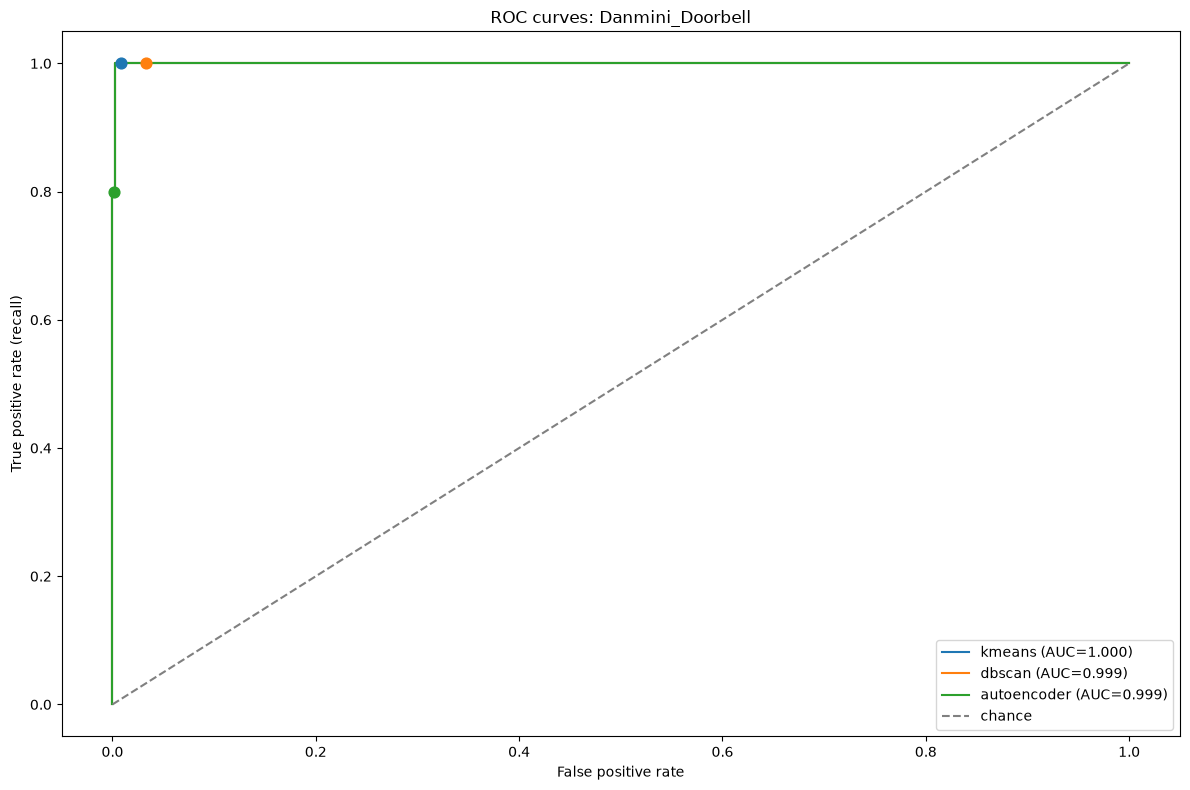

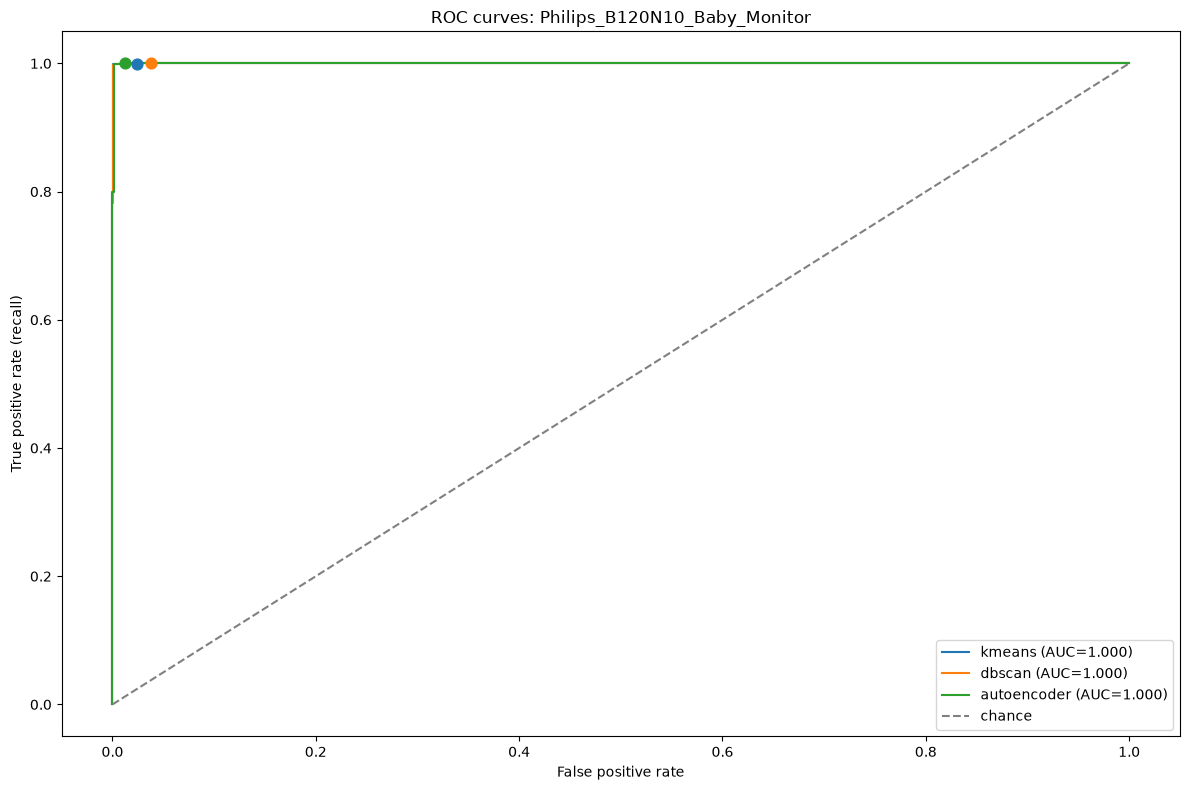

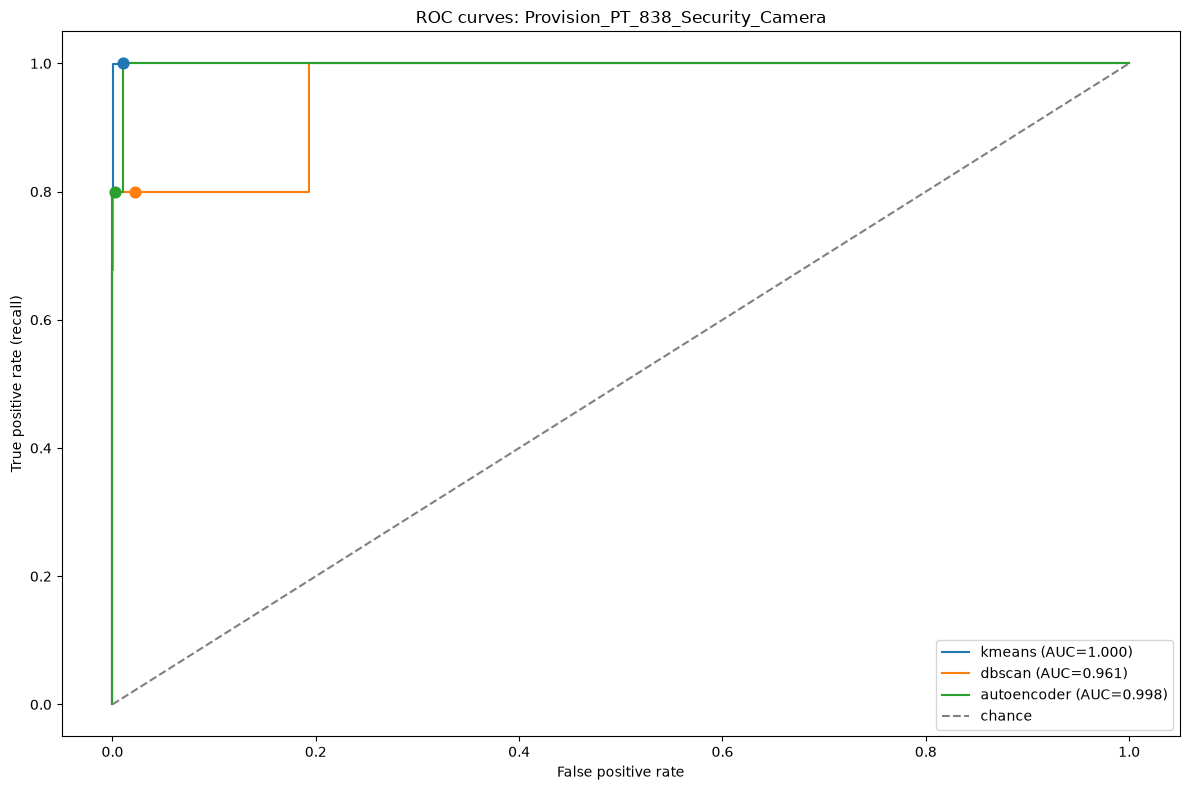

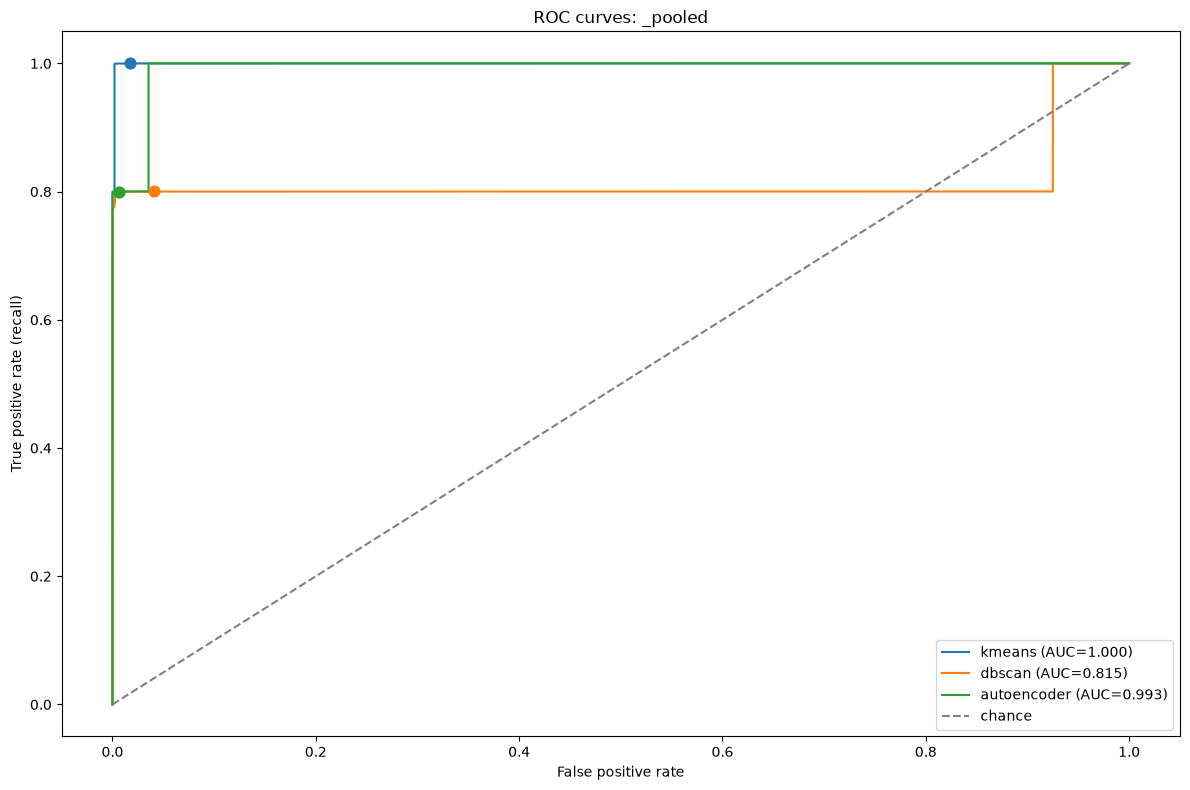

In [11]:
# Plot all three models' ROC curves per entry, marking each model's actual operating point
for entry, arrays in entry_data.items():
    figure, axis = plt.subplots(figsize=(12, 8))

    for model in models:
        false_positive_rate_curve, true_positive_rate_curve, _ = roc_curve(
            arrays["y_test"], arrays[f"{model}_score"]
        )
        row = next(r for r in metrics_rows if r["entry"] == entry and r["model"] == model)
        axis.plot(
            false_positive_rate_curve, true_positive_rate_curve,
            label=f"{model} (AUC={row['roc_auc']:.3f})",
        )
        axis.scatter([row["false_positive_rate"]], [row["recall"]], marker="o", s=60, zorder=5)

    axis.plot([0, 1], [0, 1], linestyle="--", color="grey", label="chance")
    axis.set_title(f"ROC curves: {entry}")
    axis.set_xlabel("False positive rate")
    axis.set_ylabel("True positive rate (recall)")
    axis.legend()
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"evaluation_roc_curves_{entry}.png")
    plt.show()
    plt.close(figure)

## Autoencoder reconstruction-error histogram per entry

The autoencoder's reconstruction error spans several orders of magnitude, so a linear x-axis would crush the whole benign distribution into an unreadable sliver next to the largest attack errors; the x-axis is log-scaled instead. Reconstruction error can land at, or extremely close to, zero for a well-reconstructed row, so every score is floored at a small epsilon before the log-spaced bin edges are computed, avoiding an undefined logarithm of zero.

Rows are grouped by attack family (mirai, gafgyt) rather than by the ten individual attack subtypes named in the original specification for this plot. This is a deliberate departure, not an oversight: ten overlapping histograms on one axis would be unreadable, and the family level is where the plot stays legible while still separating both attack types from benign traffic. The recovered autoencoder threshold from earlier in the notebook — the lowest flagged score, not the model's exact internal boundary — is drawn as a vertical line.

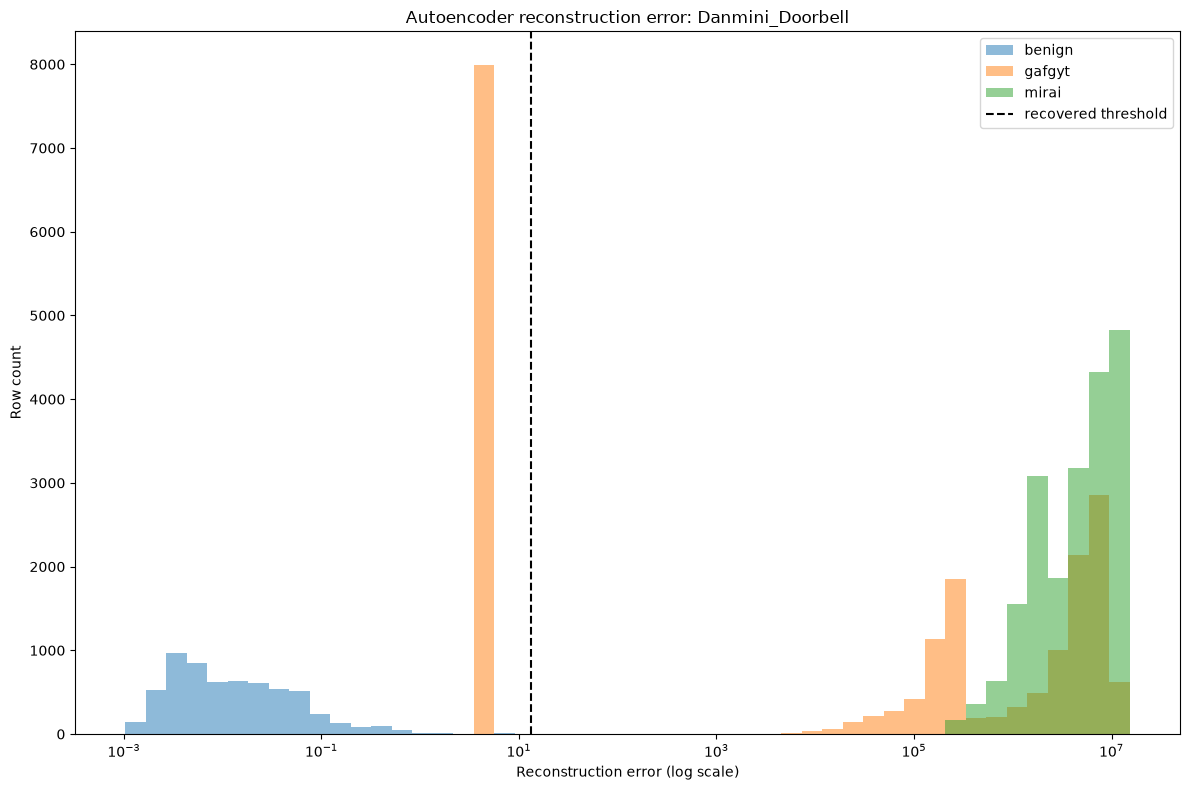

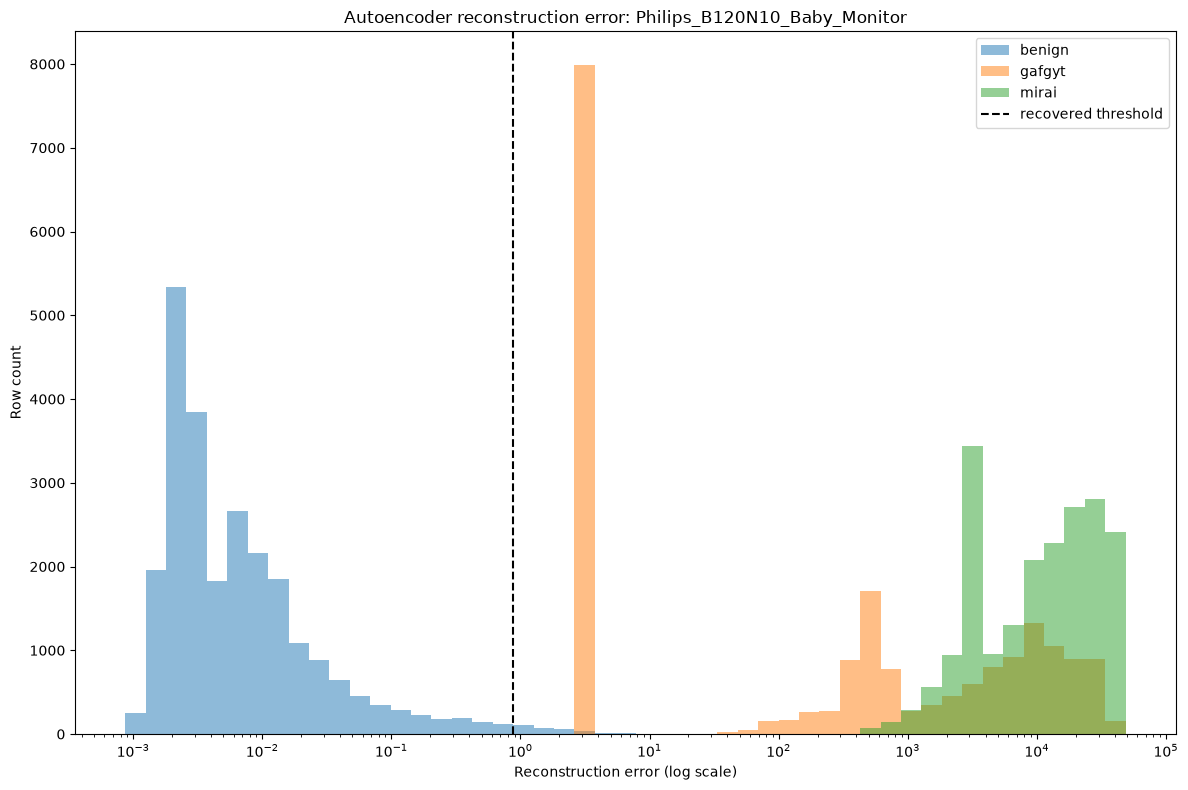

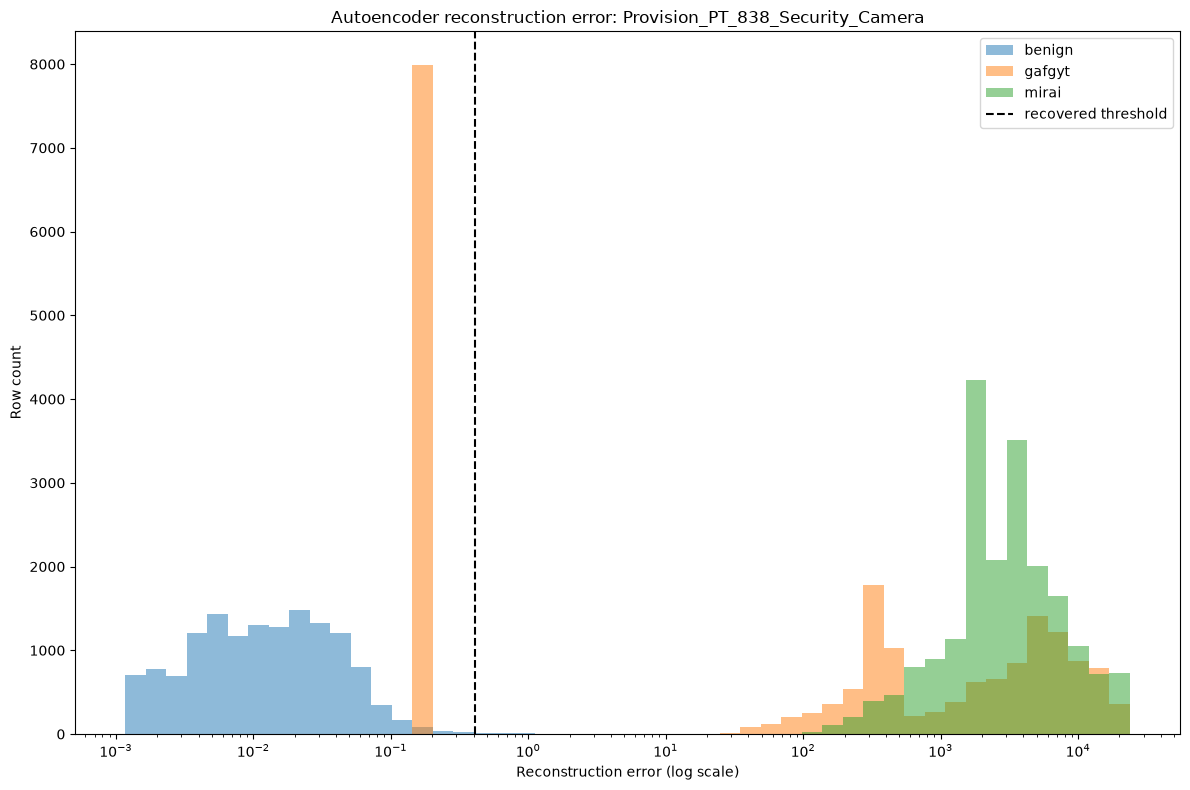

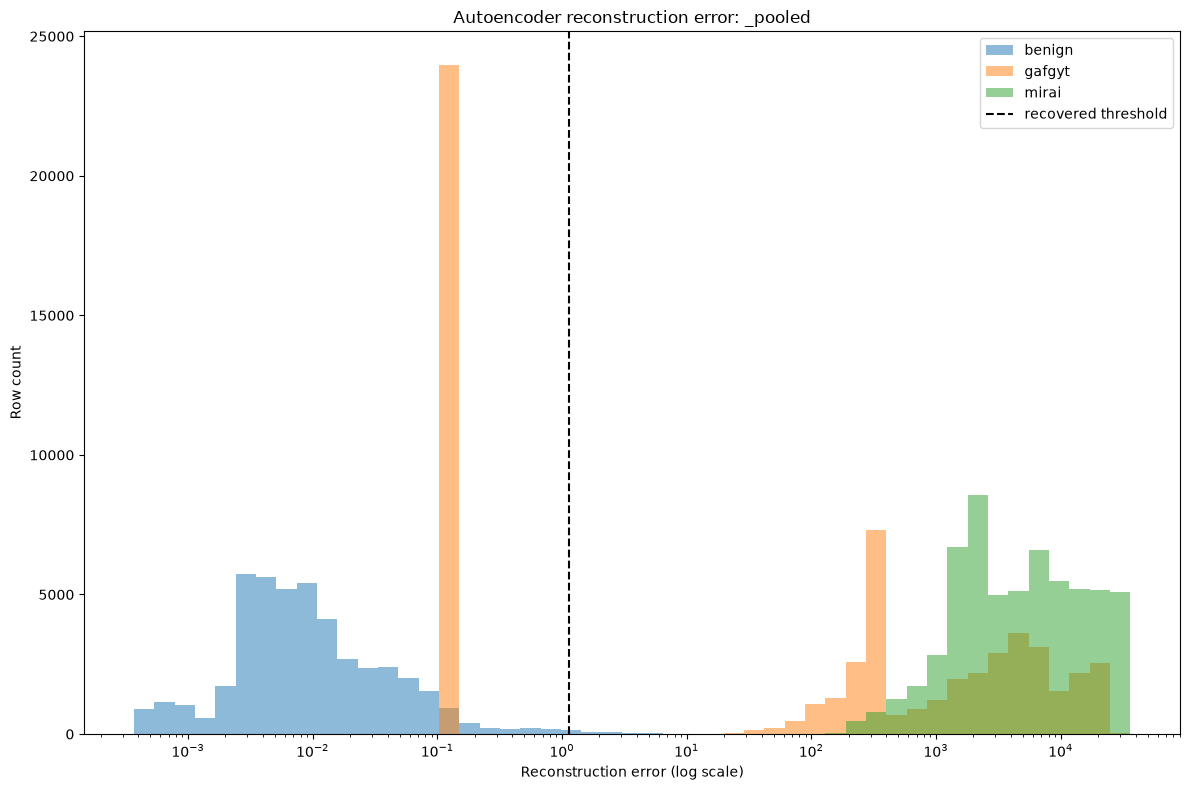

In [12]:
# Reconstruction-error histogram per entry, benign vs each attack family, on a log-scaled and epsilon-floored axis
epsilon = 1e-6
for entry, arrays in entry_data.items():
    attack_family = arrays["test_metadata"]["attack_subtype"].str.split(".").str[0]
    score = np.clip(arrays["autoencoder_score"], epsilon, None)
    bins = np.logspace(np.log10(score.min()), np.log10(score.max()), 50)

    figure, axis = plt.subplots(figsize=(12, 8))
    group_names = ["none"] + sorted(family for family in attack_family.unique() if family != "none")
    for group_name in group_names:
        group_score = score[(attack_family == group_name).to_numpy()]
        label = "benign" if group_name == "none" else group_name
        axis.hist(group_score, bins=bins, alpha=0.5, label=label)

    axis.axvline(
        threshold_by_entry_model[entry]["autoencoder"],
        color="black", linestyle="--", label="recovered threshold",
    )
    axis.set_xscale("log")
    axis.set_title(f"Autoencoder reconstruction error: {entry}")
    axis.set_xlabel("Reconstruction error (log scale)")
    axis.set_ylabel("Row count")
    axis.legend()
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"evaluation_reconstruction_error_{entry}.png")
    plt.show()
    plt.close(figure)

## Confusion matrices per entry

For every entry, the three models' confusion matrices are drawn side by side as annotated heatmaps, rows as the true label and columns as the predicted label. `seaborn`, already used for the correlation heatmap in the exploratory data analysis notebook, is reused here; the colour map is switched from that notebook's diverging `coolwarm` (appropriate for a signed correlation value) to a sequential `Blues` (appropriate for an unsigned count).

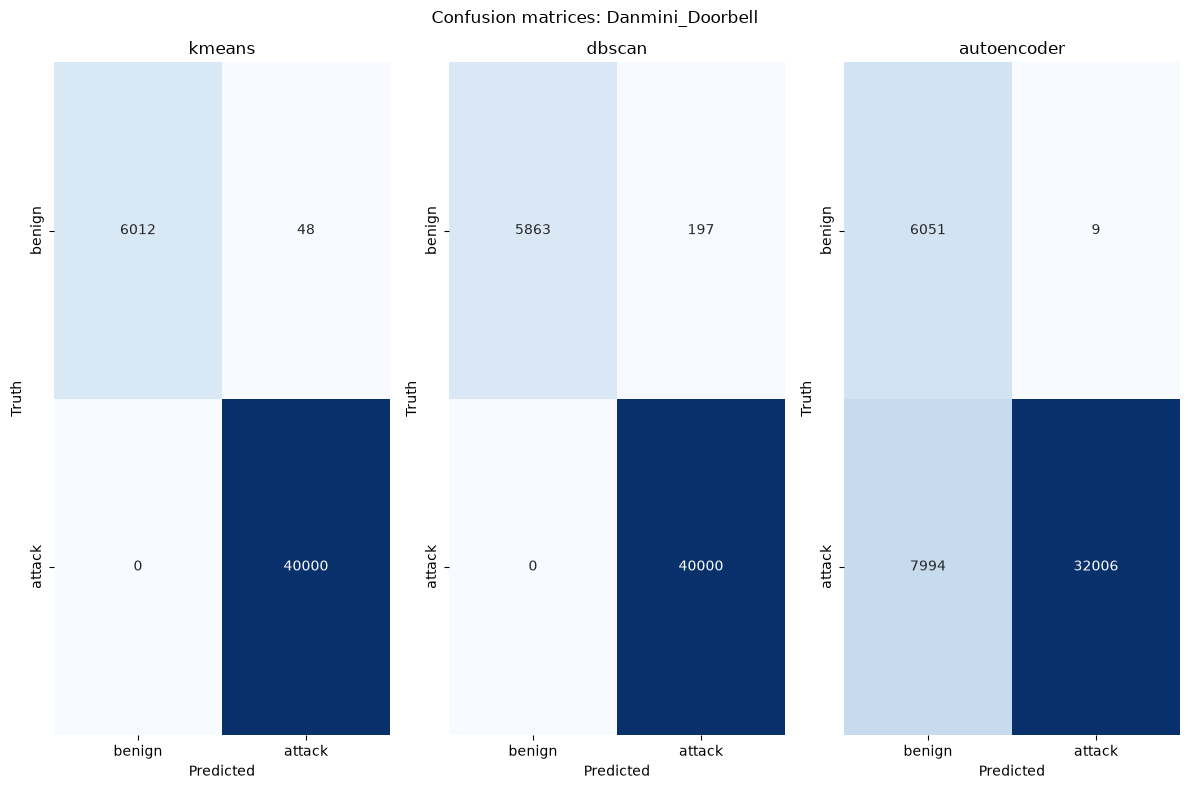

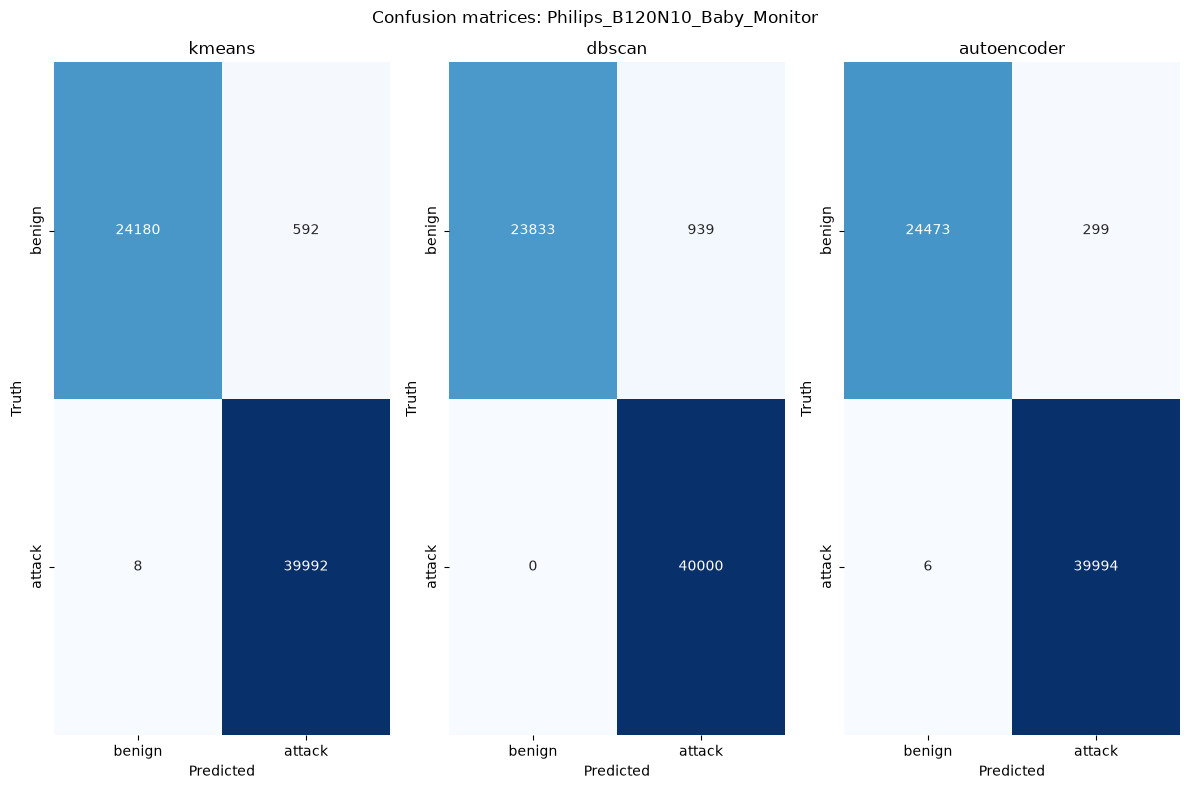

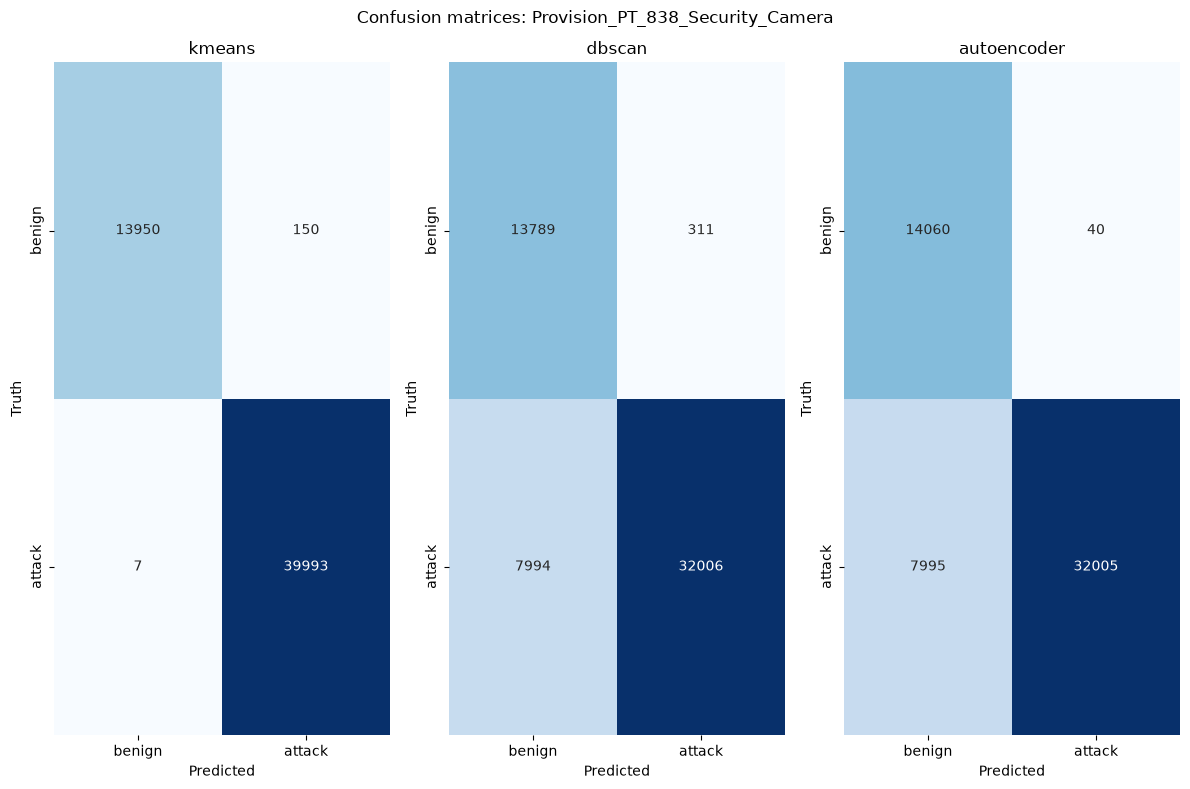

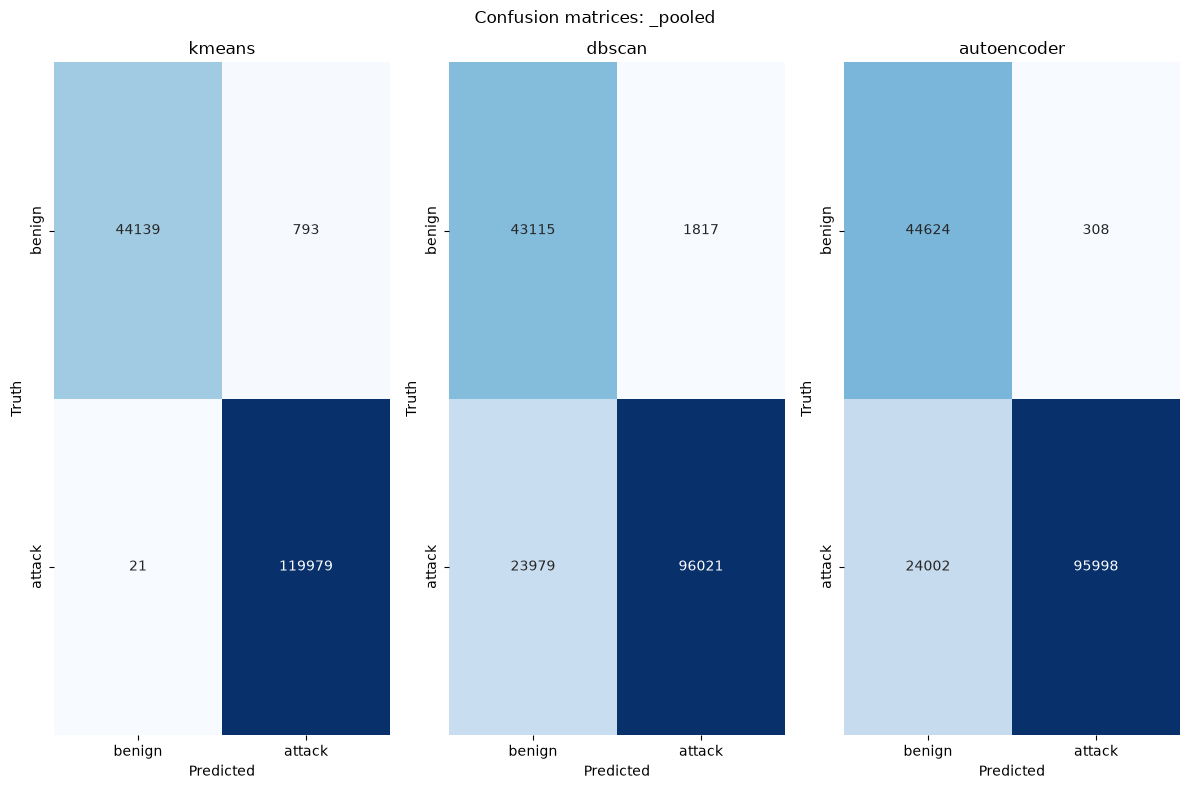

In [13]:
# Confusion matrices for all three models, side by side, per entry
for entry, arrays in entry_data.items():
    figure, axes = plt.subplots(1, 3, figsize=(12, 8))

    for axis, model in zip(axes, models):
        matrix = confusion_matrix(arrays["y_test"], arrays[f"{model}_pred"], labels=[0, 1])
        sns.heatmap(
            matrix, annot=True, fmt="d", cmap="Blues", ax=axis, cbar=False,
            xticklabels=["benign", "attack"], yticklabels=["benign", "attack"],
        )
        axis.set_title(model)
        axis.set_xlabel("Predicted")
        axis.set_ylabel("Truth")

    figure.suptitle(f"Confusion matrices: {entry}")
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"evaluation_confusion_matrices_{entry}.png")
    plt.show()
    plt.close(figure)

## Optional: detection rate by attack subtype, as a heatmap

For every entry, the detection rate for every attack subtype and model combination is drawn as a heatmap, with a fixed 0 to 1 colour range so intensity is comparable across entries. This plot goes beyond what `NOTEBOOK_PLAN.md` requires; it is offered as a more scannable companion to the `metrics_by_attack_subtype.csv` table built above.

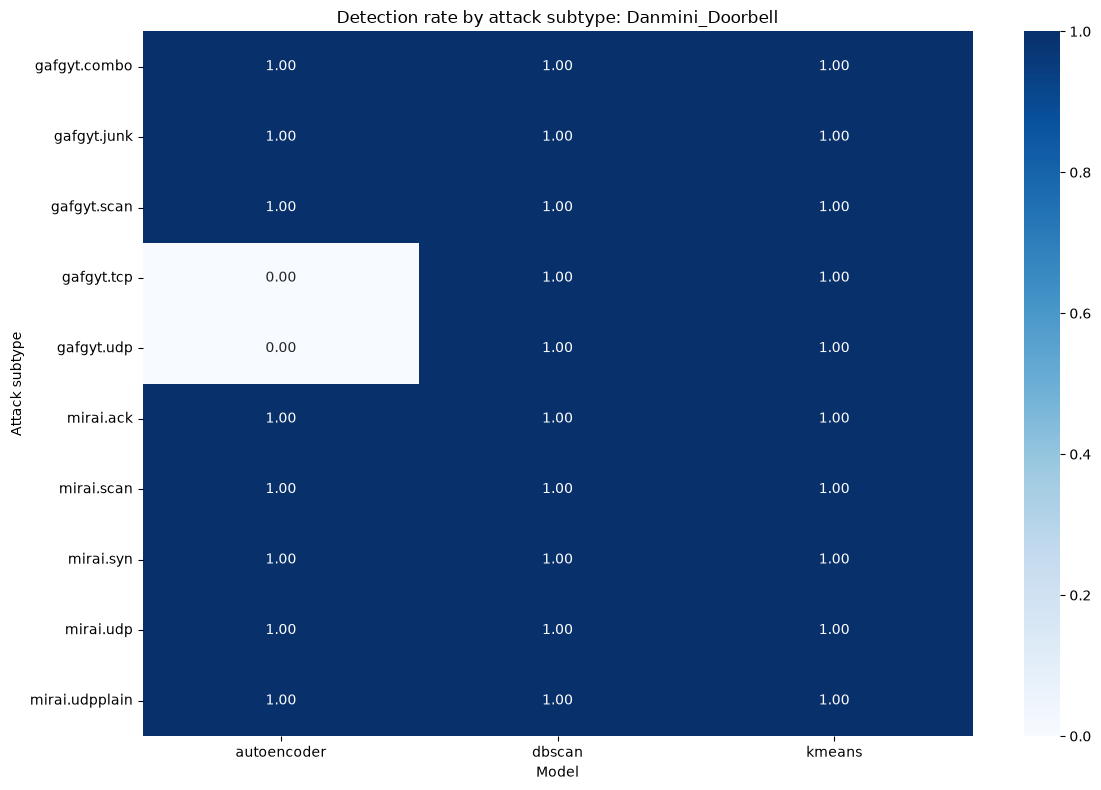

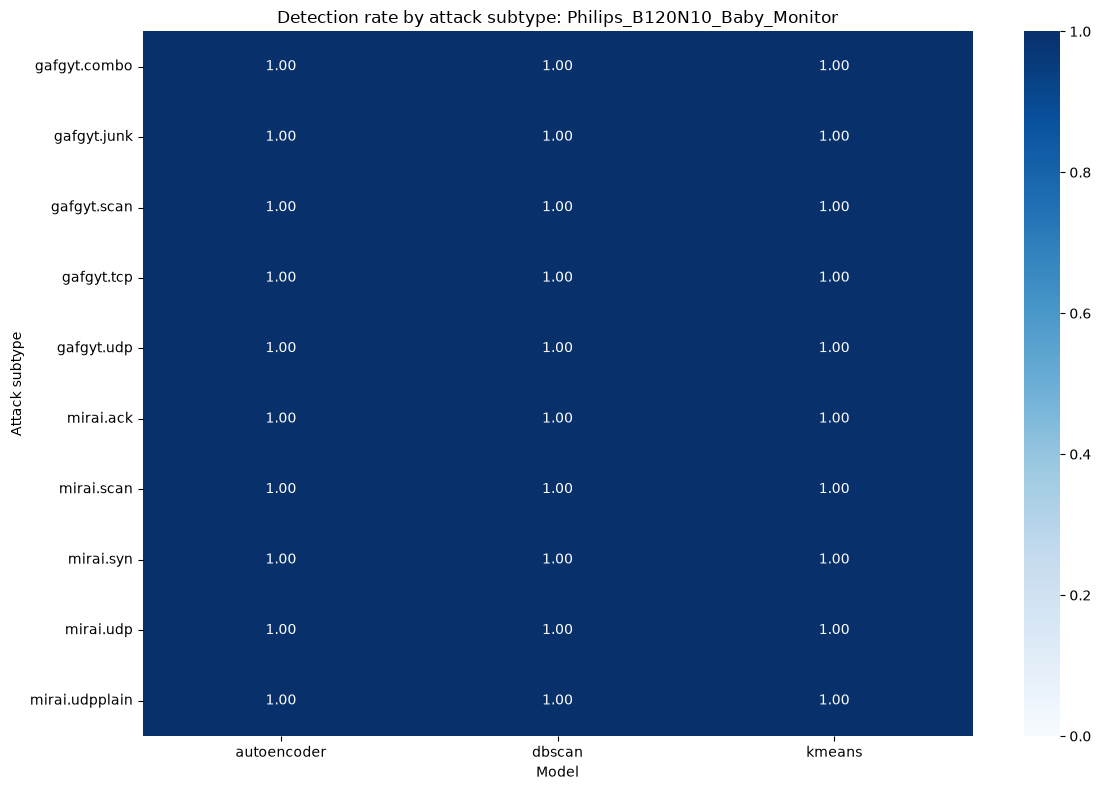

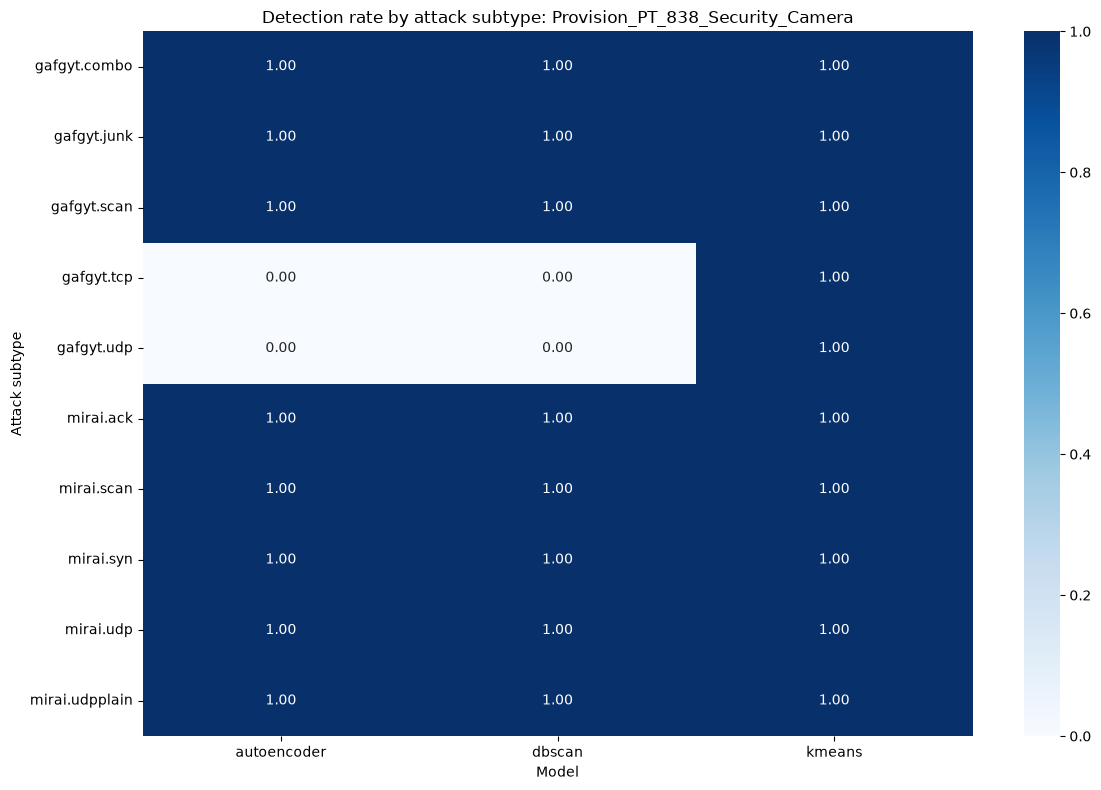

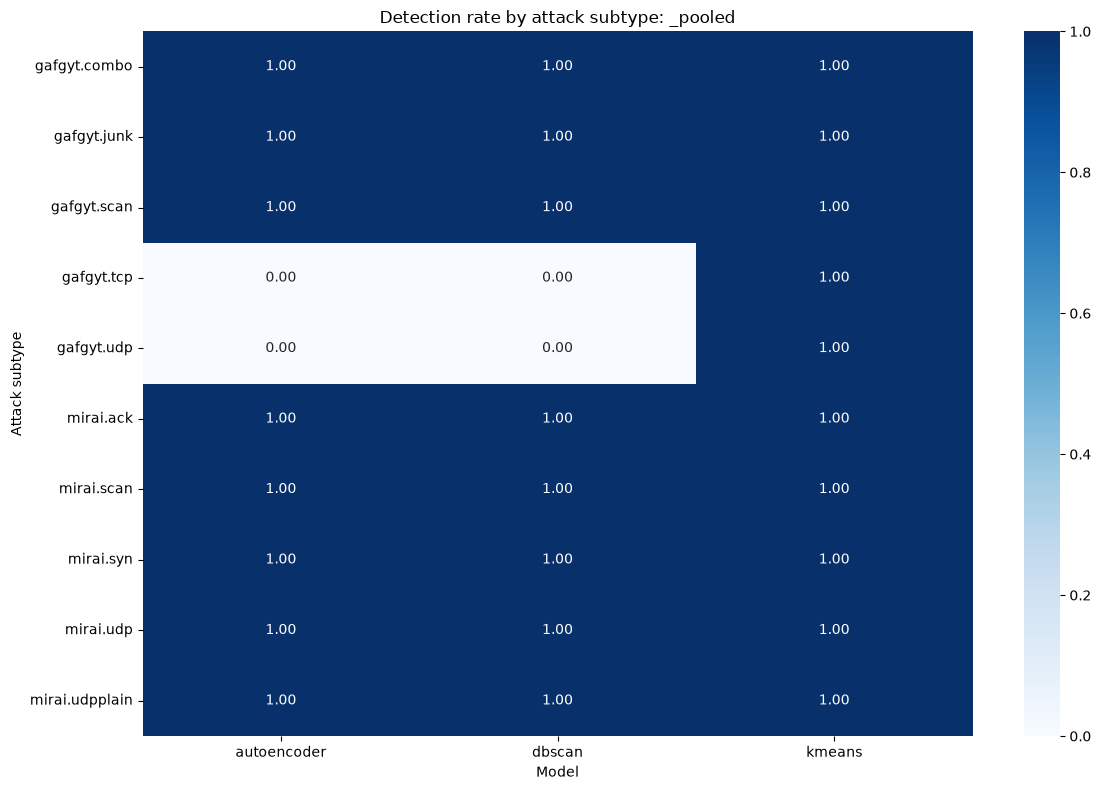

In [14]:
# Heatmap of detection rate by attack subtype and model, per entry, on a fixed 0-1 colour scale
for entry in entries:
    entry_subtypes = subtype_table[
        (subtype_table["entry"] == entry) & (subtype_table["attack_subtype"] != "none")
    ]
    pivoted = entry_subtypes.pivot(index="attack_subtype", columns="model", values="detection_rate")

    figure, axis = plt.subplots(figsize=(12, 8))
    sns.heatmap(pivoted, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axis)
    axis.set_title(f"Detection rate by attack subtype: {entry}")
    axis.set_xlabel("Model")
    axis.set_ylabel("Attack subtype")
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"evaluation_subtype_detection_{entry}.png")
    plt.show()
    plt.close(figure)

## Write the results files

`reports/metrics_summary.csv` is the one summary artefact `NOTEBOOK_PLAN.md` names for this notebook. `reports/metrics_by_attack_subtype.csv` and `reports/metrics_device_versus_pooled.csv` go beyond that: the subtype breakdown and the per-device-versus-pooled comparison each need their own table, and neither fits the summary file's per-model-per-entry schema, so they are written as two additional files instead of being squeezed into `metrics_summary.csv`. All three are written with an explicit column order, since the dictionaries built above accumulated their keys in a different order to how the columns are meant to read.

In [15]:
# Write all three result tables to reports/, in an explicit column order
summary_columns = [
    "entry", "model", "test_rows", "benign_rows", "attack_rows", "recovered_threshold",
    "true_negatives", "false_positives", "false_negatives", "true_positives",
    "precision", "recall", "f1", "false_positive_rate", "roc_auc",
]
subtype_columns = [
    "entry", "model", "attack_subtype", "attack_family", "rows", "flagged_rows", "detection_rate",
]
device_versus_pooled_columns = [
    "device", "model", "own_test_rows", "own_detection_rate", "own_false_positive_rate", "own_roc_auc",
    "pooled_slice_rows", "pooled_detection_rate", "pooled_false_positive_rate", "pooled_roc_auc",
]

metrics_table[summary_columns].to_csv(Path("reports") / "metrics_summary.csv", index=False)
subtype_table[subtype_columns].to_csv(Path("reports") / "metrics_by_attack_subtype.csv", index=False)
device_versus_pooled_table[device_versus_pooled_columns].to_csv(
    Path("reports") / "metrics_device_versus_pooled.csv", index=False
)

print(
    "Wrote reports/metrics_summary.csv, reports/metrics_by_attack_subtype.csv, "
    "and reports/metrics_device_versus_pooled.csv."
)

Wrote reports/metrics_summary.csv, reports/metrics_by_attack_subtype.csv, and reports/metrics_device_versus_pooled.csv.


## Reload and cross-check the written files

All three CSVs are reloaded from disk and checked against the row counts and columns intended above: 12 rows for the summary file (4 entries times 3 models), 132 for the subtype file (4 entries times 3 models times 11 subtypes), and 9 for the device-versus-pooled file (3 devices times 3 models). Two further cross-checks only make sense once the files exist side by side: the `"none"`-row `detection_rate` in the subtype file is the same quantity as `false_positive_rate` in the summary file, computed two different ways, so the two must agree; and `own_test_rows` must equal `pooled_slice_rows` per device, since both count exactly the same rows.

In [16]:
# Reload every written file and check its shape, columns, and cross-file consistency
reloaded_summary = pd.read_csv(Path("reports") / "metrics_summary.csv")
reloaded_subtype = pd.read_csv(Path("reports") / "metrics_by_attack_subtype.csv")
reloaded_device_versus_pooled = pd.read_csv(Path("reports") / "metrics_device_versus_pooled.csv")

assert len(reloaded_summary) == 12
assert list(reloaded_summary.columns) == summary_columns
assert len(reloaded_subtype) == 132
assert list(reloaded_subtype.columns) == subtype_columns
assert len(reloaded_device_versus_pooled) == 9
assert list(reloaded_device_versus_pooled.columns) == device_versus_pooled_columns

# Cross-check: the "none" subtype's detection_rate equals the matching false_positive_rate in the summary file
none_rows = reloaded_subtype[reloaded_subtype["attack_subtype"] == "none"]
for _, row in none_rows.iterrows():
    matching_summary_row = reloaded_summary[
        (reloaded_summary["entry"] == row["entry"]) & (reloaded_summary["model"] == row["model"])
    ].iloc[0]
    assert np.isclose(row["detection_rate"], matching_summary_row["false_positive_rate"])

# Cross-check: own_test_rows equals pooled_slice_rows per device, since both count the same rows
assert np.isclose(
    reloaded_device_versus_pooled["own_test_rows"], reloaded_device_versus_pooled["pooled_slice_rows"]
).all()

print("All three result files match their intended shape and cross-check correctly.")

All three result files match their intended shape and cross-check correctly.


## Confirm every expected figure exists

A final sweep checks that every figure this notebook was meant to save — twelve mandatory plots across the three required plot types, plus four optional subtype-detection heatmaps — is actually present on disk, matching the closing check used in the clustering and autoencoder notebooks.

In [17]:
# Sweep every expected figure path for every entry and confirm it exists
plot_prefixes = [
    "evaluation_roc_curves", "evaluation_reconstruction_error",
    "evaluation_confusion_matrices", "evaluation_subtype_detection",
]

missing_figures = []
for entry in entries:
    for prefix in plot_prefixes:
        figure_path = Path(config.FIGURE_DIRECTORY) / f"{prefix}_{entry}.png"
        if not figure_path.exists():
            missing_figures.append(str(figure_path))

assert not missing_figures, f"Missing figures: {missing_figures}"
print(f"All {len(entries) * len(plot_prefixes)} expected figures are present.")

All 16 expected figures are present.


## Findings

K-Means has the highest ROC-AUC on every one of the four entries — 0.9996 (Danmini_Doorbell), 0.9999 (Philips_B120N10_Baby_Monitor), 0.9999 (Provision_PT_838_Security_Camera), and 0.9996 (`_pooled`) — and is the most consistent model overall by this threshold-independent measure. The autoencoder is a close second almost everywhere (0.994–0.9998), except on `_pooled`, where it drops to 0.993 but still stays strong. DBSCAN is competitive with the other two on the three per-device entries (0.961–0.9998) but collapses on `_pooled` (0.815), the clearest single sign in this notebook that DBSCAN does not generalise well across devices.

Detection rate by attack subtype does not follow the "loud floods easy, quiet scans hard" intuition. Both scan subtypes are detected almost perfectly by every model everywhere. Instead, `gafgyt.tcp` and `gafgyt.udp` are the weak spot: DBSCAN and the autoencoder almost completely miss them on Danmini_Doorbell, Provision_PT_838_Security_Camera, and `_pooled` (detection rate below 0.002), while catching them almost perfectly on Philips_B120N10_Baby_Monitor; K-Means catches them almost perfectly on every entry. This single blind spot is also what produces the recurring ~0.800 recall seen for DBSCAN and the autoencoder on several entries in the metrics table above — two of ten attack subtypes going almost entirely undetected is enough to cap recall near 80% on its own.

Per-device beats pooled for DBSCAN clearly, and for the autoencoder in the one case not already limited by the `gafgyt.tcp`/`gafgyt.udp` blind spot (Philips_B120N10_Baby_Monitor: 0.9999 own versus 0.800 pooled detection rate); for K-Means the two are essentially equivalent, so a single shared threshold costs K-Means almost nothing but costs DBSCAN and the autoencoder a real amount of detection rate.

These fixed-threshold numbers — detection rate, false positive rate, and the recurring ~0.800 recall figure — are not on equal footing across models. DBSCAN's `eps` was read directly off the training k-distance curve, the same data it was fitted on, while K-Means's and the autoencoder's thresholds both came from held-out benign validation data. A threshold read off training data is optimistic by construction, so DBSCAN's precision, recall, and false positive rate throughout this notebook should be read as a looser, more favourable estimate than the other two models', and any headline "which model is best" claim should lean on ROC-AUC rather than on these fixed-threshold numbers.